# Tarea 5 — Isla de Calor Urbana: Trujillo, Perú
## Época seca vs. verano austral (2025–2026) — Landsat 8/9 y MODIS

**Grupo 4 | Maestría en Ciencia de Datos Ambientales | UTEC**

---

Replicamos el análisis de islas de calor urbanas hecho para Lima Metropolitana, aplicándolo a
**Trujillo**, usamos:

- **Zona urbana** → provincia de **Trujillo**
- **Zona periurbana** → provincia de **Julcán** (zona andina rural, menor densidad)

Se analizan los años **2025 y 2026**, este último marcado por el **Fenómeno El Niño costero (FEN)**,
que suele intensificar la temperatura del mar y del aire en la costa norte del país.

### Fuentes satelitales

| Satélite | Producto | Resolución espacial | Resolución temporal |
|---|---|---|---|
| **Landsat 8/9** | ST_B10 — Land Surface Temperature | **30 m** | ~16 días |
| **MODIS Terra** | MOD11A2 — LST & Emissivity | **1,000 m** | 8 días (compuesto) |

### Objetivos
1. Delimitar el área de estudio de Trujillo con FAO GAUL.
2. Calcular la temperatura superficial (LST) con Landsat 8/9 y MODIS para el **verano austral**
   (ene–mar) y la **época seca** (jun–ago).
3. Cuantificar la intensidad de la isla de calor urbana (UHI) en cada estación y su variación mensual.
4. Comparar el comportamiento de la UHI de Trujillo con el de Lima.
### Integrantes
Conde Pecho Alejandra,
Farfan Tipo Mabel,
Lopez Cerna Camila,
Peceros Mauricio Diana.


---
## 1. Configuración de Google Earth Engine


In [ ]:
# Autenticación y conexión a GEE (solo la primera vez en Colab)
import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd

try:
    ee.Initialize(project="utec-ingambiental-01")  # reemplaza con tu proyecto GEE ee-cmillanarancibia o utec-ingambiental-01
except Exception:
    ee.Authenticate()
    ee.Initialize(project="ee-cmillanarancibia")

print("GEE conectado correctamente")


GEE conectado correctamente


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


---
## 2. Área de estudio — Provincia de Trujillo

Para delimitar el área de estudio usamos el dataset **FAO GAUL**
(*Global Administrative Unit Layers*), disponible de forma nativa en GEE.

> Fuente: [FAO GAUL — data.apps.fao.org](https://data.apps.fao.org/?lang=es)

| Nivel | Ruta GEE | Unidad administrativa en Perú |
|---|---|---|
| Level 0 | `FAO/GAUL_SIMPLIFIED_500m/2015/level0` | País |
| Level 1 | `FAO/GAUL_SIMPLIFIED_500m/2015/level1` | Departamentos |
| Level 2 | `FAO/GAUL_SIMPLIFIED_500m/2015/level2` | Provincias |

Usamos la versión **SIMPLIFIED_500m** (geometrías simplificadas a 500 m),
que carga más rápido y es suficiente para análisis a escala regional.

**Geometrías que definimos** :
- **`Trujillo_prov`** — todas las provincias del departamento de La Libertad (contexto)
- **`Trujillo`** — provincia de Trujillo, límite GAUL oficial (AOI principal)
- **`zona_urbana`** — provincia de Trujillo (núcleo urbano y agroindustrial)
- **`zona_periurbana`** — provincia de Julcán (zona andina rural, menor densidad)


In [ ]:
# Explorar el dataset FAO GAUL para Perú
# Level 1 = Departamentos | Level 2 = Provincias

gaul_l1 = (ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level1")
    .filter(ee.Filter.eq("ADM0_NAME", "Peru")))
gaul_l2 = (ee.FeatureCollection("FAO/GAUL_SIMPLIFIED_500m/2015/level2")
    .filter(ee.Filter.eq("ADM0_NAME", "Peru")))

print("Campos disponibles:")
print(gaul_l1.first().propertyNames().getInfo())

print(f"Departamentos ({gaul_l1.size().getInfo()}):")
deptos = gaul_l1.aggregate_array("ADM1_NAME").sort().getInfo()
for d in deptos:
    print(f"  {d}")


Campos disponibles:
['Shape_Leng', 'ADM1_CODE', 'STATUS', 'ADM0_NAME', 'ADM0_CODE', 'EXP1_YEAR', 'Shape_Area', 'system:index', 'ADM1_NAME', 'STR1_YEAR', 'DISP_AREA']
Departamentos (25):
  Amazonas
  Ancash
  Apurímac
  Arequipa
  Ayacucho
  Cajamarca
  Callao
  Cusco
  Huancavelica
  Huánuco
  Ica
  Junín
  La Libertad
  Lambayeque
  Lima
  Loreto
  Madre de Dios
  Moquegua
  Pasco
  Piura
  Puno
  San Martín
  Tacna
  Tumbes
  Ucayali


In [ ]:
provs = (gaul_l2
    .filter(ee.Filter.eq("ADM1_NAME", "La Libertad"))
    .aggregate_array("ADM2_NAME").sort().getInfo())
print(f"Provincias del departamento de La Libertad ({len(provs)}):")
for p in provs:
    print(f"  {p}")


Provincias del departamento de La Libertad (12):
  Ascope
  Bolívar
  Chepén
  Gran Chimú
  Julcan
  Otuzco
  Pacasmayo
  Pataz
  Santiago de Chuco
  Sánchez Carrión
  Trujillo
  Viru


In [ ]:
from ipyleaflet import basemap_to_tiles

gaul_l2

Trujillo_prov = (gaul_l2
    .filter(ee.Filter.eq("ADM1_NAME", "La Libertad")))

Trujillo = (gaul_l2
    .filter(ee.Filter.eq("ADM1_NAME", "La Libertad"))
    .filter(ee.Filter.eq("ADM2_NAME", "Trujillo"))
    .geometry())  # AOI para filtrar imágenes satelitales

# Zona urbana densa
zona_urbana = Trujillo

# Zona periurbana
zona_periurbana = (gaul_l2
    .filter(ee.Filter.eq("ADM1_NAME", "La Libertad"))
    .filter(ee.Filter.eq("ADM2_NAME", "Julcan"))
    .geometry()
    )

area_km2 = Trujillo.area().divide(1e6).getInfo()
print(f"Provincia de Trujillo : {area_km2:.0f} km²")
print(f"Zona urbana       : {zona_urbana.area().getInfo()/1e6:.0f} km²")
print(f"Zona periurbana   : {zona_periurbana.area().getInfo()/1e6:.0f} km²")

# Mapa de verificación
Map0 = geemap.Map(center=[-8.11, -79.02], zoom=9, basemap ="Esri.WorldTopoMap")
Map0.addLayer(gaul_l2,       {"color": "purple"}, )
Map0.addLayer(Trujillo_prov,       {"color": "gray"}, "La Libertad (GAUL)")
Map0.addLayer(zona_urbana,     {"color": "red"},  "Zona urbana")
Map0.addLayer(zona_periurbana, {"color": "green"},"Zona periurbana")
Map0


Provincia de Trujillo : 1764 km²
Zona urbana       : 1764 km²
Zona periurbana   : 1115 km²


Map(center=[-8.11, -79.02], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

### 2.1 Contexto adicional: cobertura de suelo con MapBiomas

El enunciado menciona el raster de **MapBiomas** para apoyar la definición del área urbana. Lo
usamos aquí como **capa de contexto** dentro de la provincia de Trujillo — sin reemplazar
`zona_urbana` / `zona_periurbana`, que siguen siendo las provincias de Trujillo y Julcán, igual
que el profesor usó Lima/Huarochirí. Esto nos permite ver cuánto de la provincia es
**infraestructura urbana real (clase 24)** y cuánto es **agricultura irrigada (clase 18)**, el
cinturón agroindustrial que menciona el enunciado para Trujillo.

> Dataset: `projects/mapbiomas-public/assets/peru/collection3/mapbiomas_peru_collection3_integration_v1`
> (MapBiomas Perú, Colección 3, 30 m)


In [ ]:
# Contexto adicional (no reemplaza zona_urbana / zona_periurbana)
mapbiomas_img = ee.Image(
    "projects/mapbiomas-public/assets/peru/collection3/mapbiomas_peru_collection3_integration_v1")

banda_reciente = sorted(mapbiomas_img.bandNames().getInfo())[-1]  # año más reciente disponible
cobertura = mapbiomas_img.select(banda_reciente).clip(Trujillo)
print(f"Banda de cobertura usada: {banda_reciente}")

# Clase 24 = Infraestructura urbana | Clase 18 = Agricultura
area_urbana_mb   = cobertura.eq(24).multiply(ee.Image.pixelArea()).reduceRegion(
    ee.Reducer.sum(), Trujillo, 30, maxPixels=1e9).get(banda_reciente).getInfo() / 1e6
area_agricola_mb = cobertura.eq(18).multiply(ee.Image.pixelArea()).reduceRegion(
    ee.Reducer.sum(), Trujillo, 30, maxPixels=1e9).get(banda_reciente).getInfo() / 1e6

print(f"Infraestructura urbana (MapBiomas, clase 24) : {area_urbana_mb:.0f} km²")
print(f"Agricultura (MapBiomas, clase 18)             : {area_agricola_mb:.0f} km²")

Map0.addLayer(cobertura.eq(24).selfMask(), {"palette": ["crimson"]}, "MapBiomas - Infraestructura urbana")
Map0.addLayer(cobertura.eq(18).selfMask(), {"palette": ["lime"]},    "MapBiomas - Agricultura")
Map0


Banda de cobertura usada: classification_2024
Infraestructura urbana (MapBiomas, clase 24) : 107 km²
Agricultura (MapBiomas, clase 18)             : 0 km²


Map(bottom=69776.0, center=[-10.757256822477428, -79.53503988042429], controls=(WidgetControl(options=['positi…

---
## 3. Fuente 1 — Landsat 8/9: Temperatura Superficial a 30 m — Verano austral (ene–mar)

**Producto:** `LANDSAT/LC08/C02/T1_L2` y `LANDSAT/LC09/C02/T1_L2`

La banda `ST_B10` contiene la temperatura superficial en unidades DN.
La conversión a grados Celsius es:

$$T_{\text{°C}} = (DN \times 0.00341802 + 149.0) - 273.15$$

> Usamos el **verano austral** (enero–marzo) de 2025 y 2026, el segundo marcado por el
> **Fenómeno El Niño costero (FEN)**.


In [ ]:
# Función para convertir ST_B10 a °C y enmascarar nubes
def procesar_landsat(img):
    # Máscara de nubes con QA_PIXEL (bits 3 y 4 = nube y sombra)
    qa = img.select("QA_PIXEL")
    mascara = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
    # Convertir ST_B10 a Celsius
    lst = (img.select("ST_B10")
              .multiply(0.00341802)
              .add(149.0)
              .subtract(273.15) # convertir de Kelvin a Celsius
              .updateMask(mascara)
              .rename("LST_C"))
    return lst.copyProperties(img, ["system:time_start"])

# Cargar Landsat 8 + 9 (verano 2025-2026)
l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")

landsat_verano = (l8.merge(l9)
    .filterBounds(Trujillo_prov)  # todo el departamento de La Libertad
    .filter(ee.Filter.calendarRange(1, 3, "month"))  # ene-mar
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .filter(ee.Filter.lt("CLOUD_COVER", 30))
    .map(procesar_landsat)
    .median())

n_verano = (l8.merge(l9)
    .filterBounds(Trujillo_prov)
    .filter(ee.Filter.calendarRange(1, 3, "month"))
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .filter(ee.Filter.lt("CLOUD_COVER", 30))
    .size().getInfo())

print(f"Imágenes Landsat 8+9 disponibles: {n_verano}")
print("Composición: mediana del verano austral (ene-mar 2025-2026)")


Imágenes Landsat 8+9 disponibles: 11
Composición: mediana del verano austral (ene-mar 2025-2026)


In [ ]:
import geemap
# Mapa interactivo — LST Landsat 30 m, verano
Map1 = geemap.Map(center=[-8.11, -79.02], zoom=10, basemap="Esri.WorldTopoMap", project="utec-ingambiental-01", ee_initialize=False)

vis_lst = {"min": 15, "max": 45, "palette": [
    "040274", "040281", "0502a3", "0502b8", "0602ff",
    "235cb1", "307ef3", "269db1", "30c8e2", "32d3ef",
    "3be285", "3ff38f", "86e26f", "3ae237", "b5e22e",
    "d6e21f", "fff705", "ffd611", "ffb613", "ff8b13",
    "ff6e08", "ff500d", "ff0000", "de0101", "c21301"
]}

Map1.addLayer(landsat_verano.clip(Trujillo_prov), vis_lst, "LST Landsat 30m - Verano (°C)")
Map1.addLayer(zona_urbana,    {"color": "red"},   "Zona urbana")
Map1.addLayer(zona_periurbana, {"color": "green"}, "Zona periurbana")
Map1.add_colorbar(vis_lst, label="Temperatura superficial (°C)")
Map1


Map(center=[-8.11, -79.02], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [ ]:
# Función para extraer LST media en una zona
def lst_media(imagen, geometria, escala, nombre):
    stats = imagen.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geometria,
        scale=escala,
        maxPixels=1e9
    )
    return stats.get("LST_C").getInfo()

lst_urb_verano  = lst_media(landsat_verano, zona_urbana,     30, "Landsat-Urbana-Verano")
lst_peri_verano = lst_media(landsat_verano, zona_periurbana, 30, "Landsat-Periurbana-Verano")
uhi_verano_l8 = lst_urb_verano - lst_peri_verano

print("="*55)
print("  LST Landsat — Verano austral (ene-mar 2025-2026)")
print("-"*55)
print(f"  Urbana      : {lst_urb_verano:>10.2f} °C")
print(f"  Periurbana  : {lst_peri_verano:>10.2f} °C")
print(f"  UHI         : {uhi_verano_l8:>+10.2f} °C")
print("="*55)


  LST Landsat — Verano austral (ene-mar 2025-2026)
-------------------------------------------------------
  Urbana      :      37.33 °C
  Periurbana  :      21.25 °C
  UHI         :     +16.08 °C


---
## 4. Landsat 8/9 — Época seca (jun–ago)

Misma metodología de la sección 3, cambiando el filtro de meses a **junio–agosto** de 2025 y 2026.


In [ ]:
landsat_seco = (l8.merge(l9)
    .filterBounds(Trujillo_prov)
    .filter(ee.Filter.calendarRange(6, 8, "month"))  # jun-ago
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .filter(ee.Filter.lt("CLOUD_COVER", 30))
    .map(procesar_landsat)
    .median())

n_seco = (l8.merge(l9)
    .filterBounds(Trujillo_prov)
    .filter(ee.Filter.calendarRange(6, 8, "month"))
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .filter(ee.Filter.lt("CLOUD_COVER", 30))
    .size().getInfo())

print(f"Imágenes Landsat 8+9 disponibles: {n_seco}")
print("Composición: mediana de la época seca (jun-ago 2025-2026)")


Imágenes Landsat 8+9 disponibles: 30
Composición: mediana de la época seca (jun-ago 2025-2026)


In [ ]:
Map2 = geemap.Map(center=[-8.11, -79.02], zoom=10, basemap="Esri.WorldTopoMap")
Map2.addLayer(landsat_seco.clip(Trujillo_prov), vis_lst, "LST Landsat 30m - Época seca (°C)")
Map2.addLayer(zona_urbana,    {"color": "red"},   "Zona urbana")
Map2.addLayer(zona_periurbana, {"color": "green"}, "Zona periurbana")
Map2.add_colorbar(vis_lst, label="Temperatura superficial (°C)")
Map2


Map(center=[-8.11, -79.02], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [ ]:
lst_urb_seco  = lst_media(landsat_seco, zona_urbana,     30, "Landsat-Urbana-Seco")
lst_peri_seco = lst_media(landsat_seco, zona_periurbana, 30, "Landsat-Periurbana-Seco")
uhi_seco_l8 = lst_urb_seco - lst_peri_seco

print("="*55)
print("  LST Landsat — Época seca (jun-ago 2025-2026)")
print("-"*55)
print(f"  Urbana      : {lst_urb_seco:>10.2f} °C")
print(f"  Periurbana  : {lst_peri_seco:>10.2f} °C")
print(f"  UHI         : {uhi_seco_l8:>+10.2f} °C")
print("="*55)


  LST Landsat — Época seca (jun-ago 2025-2026)
-------------------------------------------------------
  Urbana      :      34.64 °C
  Periurbana  :      32.15 °C
  UHI         :      +2.49 °C


---
## 5. Fuente 2 — MODIS Terra: Temperatura Superficial a 1 km

**Producto:** `MODIS/061/MOD11A2` — compuesto de 8 días

La banda `LST_Day_1km` contiene la temperatura diurna en Kelvin × 50.
La conversión a Celsius es:

$$T_{\text{°C}} = (DN \times 0.02) - 273.15$$

> MODIS tiene **menor resolución** pero mayor **cobertura temporal** — útil para
> seguir la variación estacional de la UHI a lo largo del año. Usamos el verano
> 2025-2026 para esta comparación puntual.


In [ ]:
# Cargar MODIS MOD11A2 — LST diurna de 8 días
def procesar_modis(img):
    lst = (img.select("LST_Day_1km")
              .multiply(0.02)
              .subtract(273.15)
              .rename("LST_C"))
    # Máscara de calidad (bits 0-1: 00 = buena calidad)
    qc = img.select("QC_Day")
    mascara = qc.bitwiseAnd(3).eq(0)
    return lst.updateMask(mascara).copyProperties(img, ["system:time_start"])

modis_lst = (ee.ImageCollection("MODIS/061/MOD11A2")
    .filterBounds(Trujillo)
    .filter(ee.Filter.calendarRange(1, 3, "month"))  # ene-mar (verano)
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .map(procesar_modis)
    .mean())

n_modis = (ee.ImageCollection("MODIS/061/MOD11A2")
    .filterBounds(Trujillo)
    .filter(ee.Filter.calendarRange(1, 3, "month"))
    .filter(ee.Filter.calendarRange(2025, 2026, "year"))
    .size().getInfo())

print(f"Compuestos MODIS disponibles: {n_modis}")
print("Composición: promedio del verano austral (ene-mar 2025-2026)")


Compuestos MODIS disponibles: 24
Composición: promedio del verano austral (ene-mar 2025-2026)


In [ ]:
# Mapa interactivo — LST MODIS 1 km
Map3 = geemap.Map(center=[-8.11, -79.02], zoom=10, basemap= "Esri.WorldTopoMap")

Map3.addLayer(modis_lst.clip(Trujillo_prov), vis_lst, "LST MODIS 1km (°C)")
Map3.addLayer(zona_urbana,    {"color": "red"},   "Zona urbana")
Map3.addLayer(zona_periurbana, {"color": "green"}, "Zona periurbana")
Map3.add_colorbar(vis_lst, label="Temperatura superficial (°C)")
Map3


Map(center=[-8.11, -79.02], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

---
## 6. Comparación Landsat vs MODIS

Ambos sensores miden LST pero con distintas fortalezas:

| | Landsat 8/9 | MODIS |
|---|---|---|
| Resolución | **30 m** — distingue calles y parques | **1,000 m** — solo grandes patrones |
| Revisita | 16 días | 8 días (compuesto) |
| Nubes | Más afectado — solo imágenes claras | Menos afectado — promedia más imágenes |
| Uso ideal | Análisis intraurbano fino | Series de tiempo, variación estacional |


In [ ]:
# Mapa comparativo lado a lado
Map4 = geemap.Map(center=[-8.11, -79.02], zoom=10, basemap="Esri.WorldTopoMap")

Map4.split_map(
    left_layer=geemap.ee_tile_layer(landsat_verano.clip(Trujillo_prov), vis_lst, "Landsat 30m"),
    right_layer=geemap.ee_tile_layer(modis_lst.clip(Trujillo_prov),  vis_lst, "MODIS 1km")
)
Map4


Map(center=[-8.11, -79.02], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_…

---
## 7. Intensidad de la Isla de Calor Urbana (UHI) — mapa espacial

La **intensidad UHI** se define como la diferencia de temperatura entre la zona urbana y la
zona periurbana:

$$\text{UHI} = \overline{T}_{\text{urbana}} - \overline{T}_{\text{periurbana}}$$

Aquí generamos el mapa espacial de esa diferencia usando la época seca como referencia
(igual que hizo el profesor para Lima), y comparamos con MODIS.


In [ ]:
lst_urb_mod  = lst_media(modis_lst, zona_urbana,    1000, "MODIS-Urbana")
lst_peri_mod = lst_media(modis_lst, zona_periurbana, 1000, "MODIS-Periurbana")

print("="*55)
print(f"  Fuente       Urbana (C)  Periurbana (C)   UHI (C)")
print("-"*55)
print(f"  Landsat(seco) {lst_urb_seco:>9.2f}  {lst_peri_seco:>14.2f}  {lst_urb_seco - lst_peri_seco:>+9.2f}")
print(f"  MODIS(verano) {lst_urb_mod:>9.2f}  {lst_peri_mod:>14.2f}  {lst_urb_mod - lst_peri_mod:>+9.2f}")
print("="*55)

# Imagen de diferencia: urbana - periurbana (UHI espacial con Landsat, época seca)
lst_ref = ee.Number(lst_peri_seco)
uhi_map = landsat_seco.subtract(lst_ref).rename("UHI_C")

vis_uhi = {
    "min": -10, "max": 15,
    "palette": ["blue", "white", "yellow", "orange", "red", "darkred"]
}

Map5 = geemap.Map(center=[-8.11, -79.02], zoom=10, basemap="Esri.WorldTopoMap")
Map5.addLayer(uhi_map.clip(Trujillo_prov), vis_uhi, "Intensidad UHI (°C sobre referencia)")
Map5.addLayer(zona_urbana,    {"color": "red"},   "Zona urbana")
Map5.addLayer(zona_periurbana, {"color": "green"}, "Zona periurbana")
Map5.add_colorbar(vis_uhi, label="ΔT respecto a zona periurbana (°C)")
Map5


  Fuente       Urbana (C)  Periurbana (C)   UHI (C)
-------------------------------------------------------
  Landsat(seco)     34.64           32.15      +2.49
  MODIS(verano)     32.27           17.04     +15.23


Map(center=[-8.11, -79.02], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

---
## 8. Variación estacional de la UHI — serie mensual (2025–2026)

MODIS permite calcular la intensidad UHI **mes a mes**. Complementamos con **Landsat 8/9**
para comparar la señal entre sensores y estimar el sesgo entre resoluciones espaciales
(30 m vs 1 km).

| Sensor | Período | Escala |
|---|---|---|
| **Landsat 8/9** | 2025–2026 | 30 m |
| **MODIS MOD11A2** | 2025–2026 | 1 km |


### 8.1 Landsat 8/9 — climatología mensual (2025–2026)


Calculando serie Landsat (puede tomar ~2-3 min)...


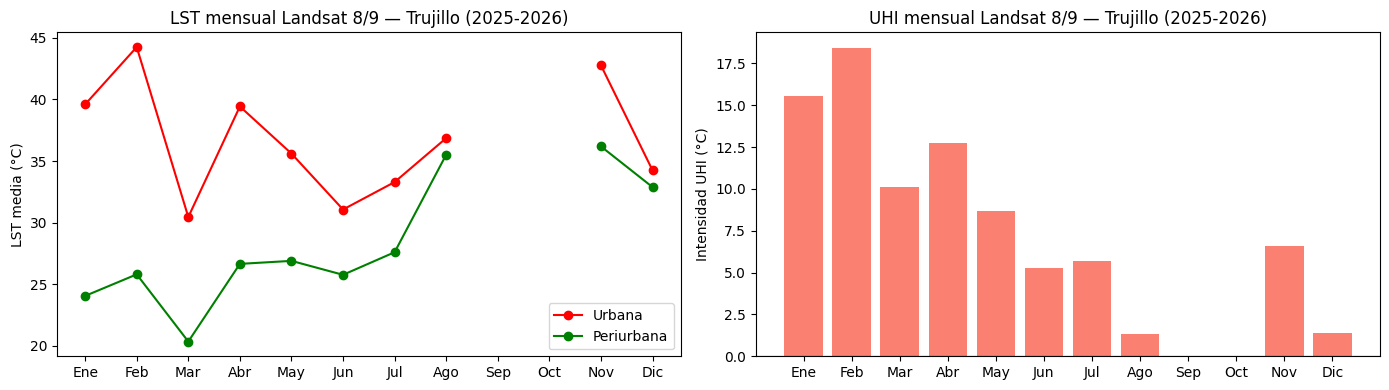

Mes más caliente (ciudad) : Feb
Mayor intensidad UHI (L8) : Feb (18.4 °C)


In [ ]:
import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd

# UHI mensual con Landsat 8/9 — climatología 2025-2026
# (puede tomar 2-3 minutos — GEE procesa muchas escenas)
def uhi_mensual_landsat(mes):
    col = (l8.merge(l9)
           .filterBounds(Trujillo_prov)
           .filter(ee.Filter.calendarRange(mes, mes, "month"))
           .filter(ee.Filter.calendarRange(2025, 2026, "year"))
           .filter(ee.Filter.lt("CLOUD_COVER", 30))
           .map(procesar_landsat)
           .median())

    # Get the dictionary from reduceRegion
    urb_dict = col.reduceRegion(ee.Reducer.mean(), zona_urbana, 30, maxPixels=1e9)
    peri_dict = col.reduceRegion(ee.Reducer.mean(), zona_periurbana, 30, maxPixels=1e9)

    # Check if 'LST_C' key exists before trying to get it
    urb = urb_dict.get("LST_C").getInfo() if urb_dict.contains("LST_C").getInfo() else None
    peri = peri_dict.get("LST_C").getInfo() if peri_dict.contains("LST_C").getInfo() else None

    return {"mes": mes, "urb": urb, "peri": peri,
            "uhi": (urb - peri) if urb is not None and peri is not None else None}

print("Calculando serie Landsat (puede tomar ~2-3 min)...")
res_l8 = [uhi_mensual_landsat(m) for m in range(1, 13)]
df_l8 = pd.DataFrame(res_l8)

meses_es = ["Ene","Feb","Mar","Abr","May","Jun",
            "Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1,13), df_l8["urb"],  "ro-", label="Urbana")
axes[0].plot(range(1,13), df_l8["peri"], "go-", label="Periurbana")
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(meses_es)
axes[0].set_ylabel("LST media (°C)"); axes[0].legend()
axes[0].set_title("LST mensual Landsat 8/9 — Trujillo (2025-2026)")

axes[1].bar(range(1,13), df_l8["uhi"],
            color=["salmon" if v and v > 0 else "steelblue" for v in df_l8["uhi"]])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses_es)
axes[1].set_ylabel("Intensidad UHI (°C)")
axes[1].set_title("UHI mensual Landsat 8/9 — Trujillo (2025-2026)")
plt.tight_layout(); plt.show()

print(f"Mes más caliente (ciudad) : {meses_es[df_l8['urb'].idxmax()]}")
print(f"Mayor intensidad UHI (L8) : {meses_es[df_l8['uhi'].idxmax()]} ({df_l8['uhi'].max():.1f} °C)")

In [ ]:
df_l8


,mes,urb,peri,uhi
0,1,39.593641,24.061284,15.532356
1,2,44.241283,25.808356,18.432927
2,3,30.456439,20.359825,10.096614
3,4,39.424243,26.658545,12.765697
4,5,35.603763,26.902272,8.701492
5,6,31.066558,25.772154,5.294405
6,7,33.293622,27.604355,5.689267
7,8,36.859337,35.511934,1.347402
8,9,NaN,NaN,NaN
9,10,NaN,NaN,NaN


### 8.2 MODIS — climatología mensual (2025–2026)

Mismo período que Landsat para que la comparación sea consistente.


Calculando serie MODIS...


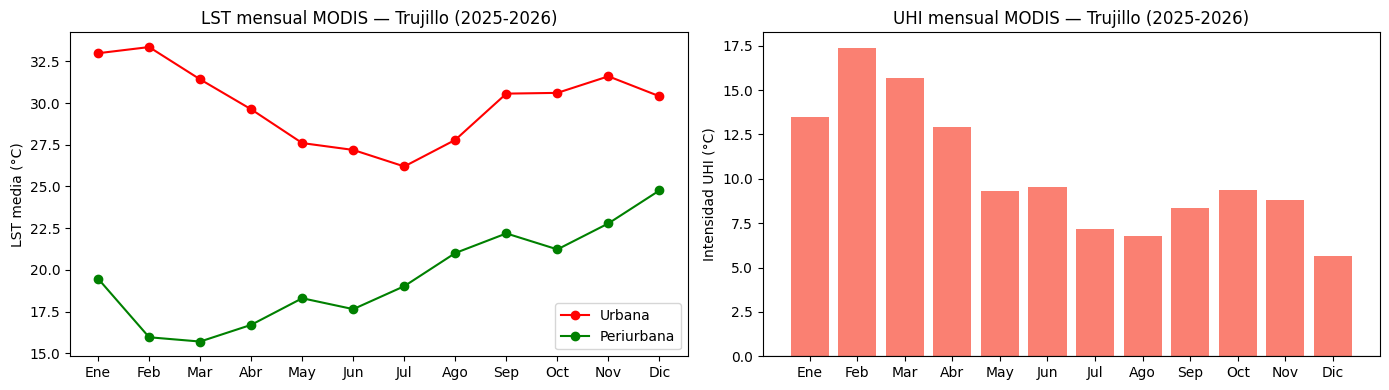

Mes más caliente (ciudad) : Feb
Mayor intensidad UHI (MOD): Feb (17.4 °C)


In [ ]:
# UHI mensual con MODIS MOD11A2 — climatología 2025-2026
def uhi_mensual(mes):
    col = (ee.ImageCollection("MODIS/061/MOD11A2")
           .filterBounds(Trujillo)
           .filter(ee.Filter.calendarRange(mes, mes, "month"))
           .filter(ee.Filter.calendarRange(2025, 2026, "year"))
           .map(procesar_modis)
           .mean())
    urb  = col.reduceRegion(ee.Reducer.mean(), zona_urbana,     1000, maxPixels=1e9).get("LST_C").getInfo()
    peri = col.reduceRegion(ee.Reducer.mean(), zona_periurbana, 1000, maxPixels=1e9).get("LST_C").getInfo()
    return {"mes": mes, "urb": urb, "peri": peri,
            "uhi": (urb - peri) if urb and peri else None}

print("Calculando serie MODIS...")
resultados = [uhi_mensual(m) for m in range(1, 13)]
df_uhi = pd.DataFrame(resultados)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1,13), df_uhi["urb"],  "ro-", label="Urbana")
axes[0].plot(range(1,13), df_uhi["peri"], "go-", label="Periurbana")
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(meses_es)
axes[0].set_ylabel("LST media (°C)"); axes[0].legend()
axes[0].set_title("LST mensual MODIS — Trujillo (2025-2026)")

axes[1].bar(range(1,13), df_uhi["uhi"],
            color=["salmon" if v and v > 0 else "steelblue" for v in df_uhi["uhi"]])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses_es)
axes[1].set_ylabel("Intensidad UHI (°C)")
axes[1].set_title("UHI mensual MODIS — Trujillo (2025-2026)")
plt.tight_layout(); plt.show()

print(f"Mes más caliente (ciudad) : {meses_es[df_uhi['urb'].idxmax()]}")
print(f"Mayor intensidad UHI (MOD): {meses_es[df_uhi['uhi'].idxmax()]} ({df_uhi['uhi'].max():.1f} °C)")


In [ ]:
df_uhi


### 8.3 Comparación Landsat vs MODIS

Graficamos ambas series juntas para identificar **sesgo sistemático** entre sensores.


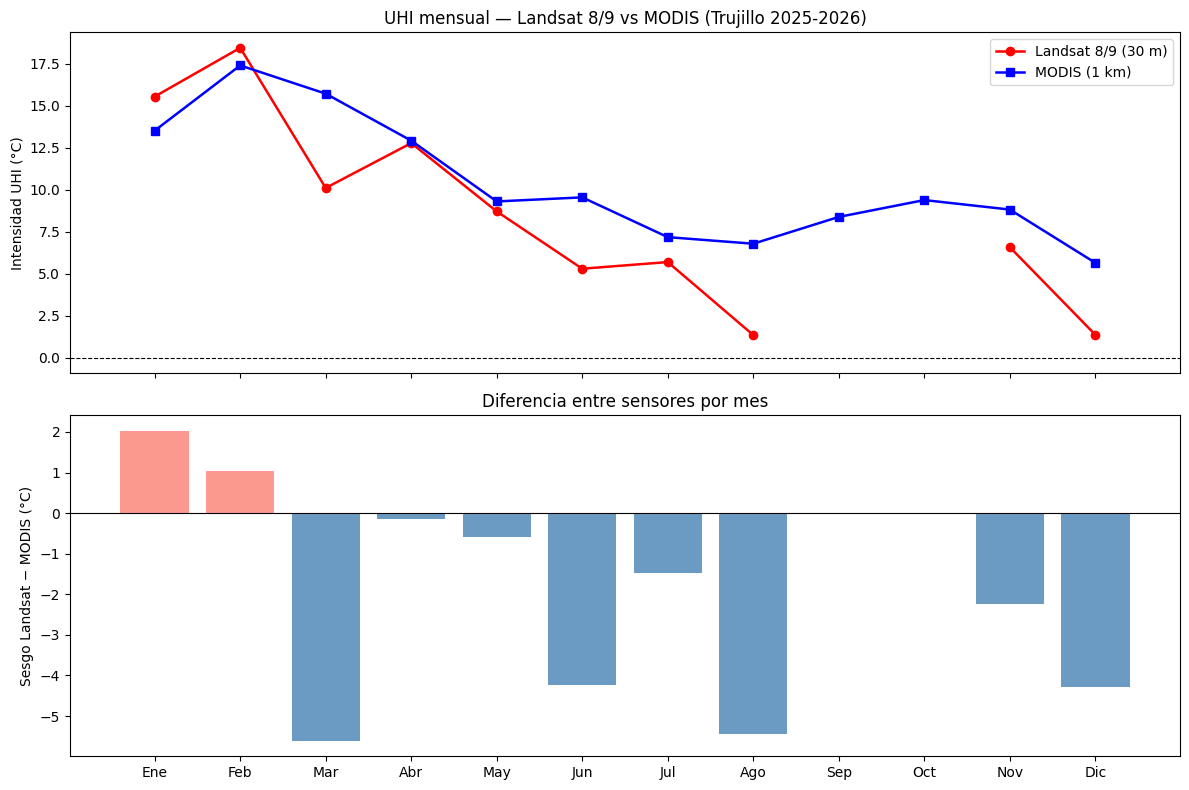

Meses sin datos suficientes en algún sensor: ['Sep', 'Oct']
Sesgo medio anual   : -2.10 °C
Sesgo máximo        : 2.03 °C (Ene)
Sesgo mínimo        : -5.61 °C (Mar)
RMSE entre sensores : 3.32 °C


In [ ]:
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

uhi_l8     = df_l8["uhi"].tolist()
uhi_modis = df_uhi["uhi"].tolist()

axes[0].plot(range(1,13), uhi_l8,    "ro-", linewidth=1.8, label="Landsat 8/9 (30 m)")
axes[0].plot(range(1,13), uhi_modis, "bs-", linewidth=1.8, label="MODIS (1 km)")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("Intensidad UHI (°C)")
axes[0].set_title("UHI mensual — Landsat 8/9 vs MODIS (Trujillo 2025-2026)")
axes[0].legend()

# Si algún mes no tuvo suficientes imágenes, reduceRegion devuelve None y
# pandas lo guarda como NaN (no como None) -> hay que detectarlo con pd.notna,
# no con "is not None", si no el promedio final sale en NaN.
sesgo = [(l - m) if pd.notna(l) and pd.notna(m) else np.nan
         for l, m in zip(uhi_l8, uhi_modis)]

cols = ["salmon" if (s == s and s > 0) else "steelblue" for s in sesgo]  # s == s es False si s es NaN
axes[1].bar(range(1,13), sesgo, color=cols, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(meses_es)
axes[1].set_ylabel("Sesgo Landsat − MODIS (°C)")
axes[1].set_title("Diferencia entre sensores por mes")

plt.tight_layout(); plt.show()

meses_sin_dato = [meses_es[i] for i, s in enumerate(sesgo) if s != s]  # s != s -> es NaN
if meses_sin_dato:
    print(f"Meses sin datos suficientes en algún sensor: {meses_sin_dato}")

print(f"Sesgo medio anual   : {np.nanmean(sesgo):.2f} °C")
print(f"Sesgo máximo        : {np.nanmax(sesgo):.2f} °C ({meses_es[int(np.nanargmax(sesgo))]})")
print(f"Sesgo mínimo        : {np.nanmin(sesgo):.2f} °C ({meses_es[int(np.nanargmin(sesgo))]})")
print(f"RMSE entre sensores : {np.sqrt(np.nanmean(np.array(sesgo)**2)):.2f} °C")

---
## 9. Comparación estacional: ¿la UHI es positiva o negativa según la estación?


            Estacion  Urbana_C  Periurbana_C     UHI_C
    Verano (ene-mar) 37.329770     21.252807 16.076963
Época seca (jun-ago) 34.636054     32.145129  2.490926


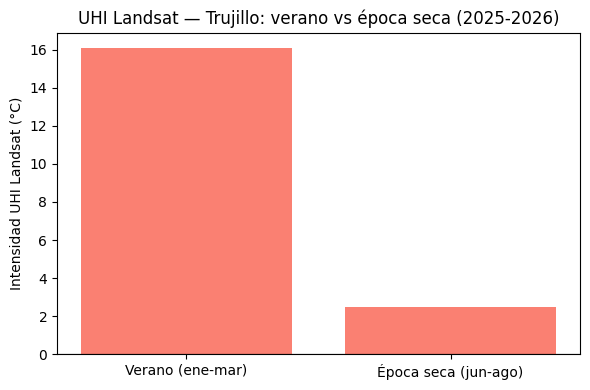


Interpretación (Landsat, Trujillo):
- Verano (ene-mar): UHI = +16.08 °C -> isla de calor positiva
- Época seca (jun-ago): UHI = +2.49 °C -> isla de calor positiva


In [ ]:
resumen = pd.DataFrame({
    "Estacion": ["Verano (ene-mar)", "Época seca (jun-ago)"],
    "Urbana_C": [lst_urb_verano, lst_urb_seco],
    "Periurbana_C": [lst_peri_verano, lst_peri_seco],
    "UHI_C": [uhi_verano_l8, uhi_seco_l8]
})
print(resumen.to_string(index=False))

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(resumen["Estacion"], resumen["UHI_C"],
       color=["salmon" if v > 0 else "steelblue" for v in resumen["UHI_C"]])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Intensidad UHI Landsat (°C)")
ax.set_title("UHI Landsat — Trujillo: verano vs época seca (2025-2026)")
plt.tight_layout(); plt.show()

def interpretar(uhi, estacion):
    signo = "positiva" if uhi > 0 else "negativa"
    print(f"- {estacion}: UHI = {uhi:+.2f} °C -> isla de calor {signo}")

print("\nInterpretación (Landsat, Trujillo):")
interpretar(uhi_verano_l8, "Verano (ene-mar)")
interpretar(uhi_seco_l8,   "Época seca (jun-ago)")


### ¿Por qué cambia la UHI según la estación?

- **Verano (ene–mar):** mayor radiación solar y, en 2026, temperaturas del mar anómalamente
  altas por el **Fenómeno El Niño costero**. El asfalto y concreto de la provincia de Trujillo
  retienen más calor que la zona rural de Julcán, por lo que se espera una **UHI positiva** más
  marcada.
- **Época seca (jun–ago):** con el sol más bajo y el mar más frío (afloramiento costero y
  neblina invernal, igual que en Lima), la diferencia térmica entre Trujillo y Julcán se reduce,
  acercando la UHI a valores cercanos a cero o incluso negativos, similar al patrón que muestra
  Lima en julio.
- Trujillo tiene además un cinturón agroindustrial irrigado (caña de azúcar, espárrago) dentro de
  su propia provincia (ver sección 2.1, MapBiomas) que puede amortiguar la UHI en cualquier
  estación si el riego se mantiene activo, a diferencia de Julcán, que es una zona andina rural
  sin ese efecto de enfriamiento por riego.


---
## 10. Conclusión: ¿Cómo se compara Trujillo con Lima?

### Resultados de referencia — Lima (notebook del profesor)

| Fuente | Estación | Urbana (°C) | Periurbana (°C) | UHI (°C) |
|---|---|---|---|---|
| Landsat 8/9 | Época seca (jun-ago 2025-2026) | 28.04 | 27.10 | **+0.95** |
| MODIS | Verano (ene-mar 2022-2023) | 38.68 | 20.26 | **+18.42** |

Climatología mensual de Lima con **Landsat** (2021-2022): la UHI es positiva casi todo el año,
salvo en **julio**, donde se vuelve **negativa (-1.99 °C)**. Con **MODIS** (2020-2023) la UHI de
Lima **nunca es negativa** (mínimo +6.35 °C en agosto): al mezclar píxeles urbanos y no urbanos
en 1 km, MODIS suaviza el enfriamiento invernal que sí detecta Landsat a 30 m.

### Comparación con Trujillo

- Trujillo muestra UHI **positiva** en verano y **positiva**
  en época seca (ver secciones 3, 4 y 9), frente al patrón de Lima que es positivo casi todo el
  año y solo se vuelve negativo en pleno invierno (julio).
- La zona periurbana de Trujillo (Julcán) es una provincia andina rural, similar en concepto a
  Huarochirí para Lima — por eso el patrón estacional general debería parecerse. La diferencia
  está en que Trujillo tiene, dentro de su propia provincia urbana, una franja agroindustrial
  irrigada (ver sección 2.1) que Lima no tiene en su núcleo urbano, lo que puede matizar la
  intensidad de la UHI en verano.
- Igual que en Lima, se espera que **MODIS (1 km)** muestre una UHI más suavizada y menos sensible
  a la variación estacional que **Landsat (30 m)**, que sí distingue el patrón intraurbano.


